In [2]:
using JLD2
using Plots
using LaTeXStrings

In [ ]:
dir = "../send2/"
files = readdir(dir)
files = filter(f -> endswith(f, ".jld2"), files)

# println(files)

data = Dict{Tuple{Int,Int,Int}, Any}()
for file in files
    path = joinpath(dir, file)
    params = match(r"optimal_decoder_2_L(\d+)_T(\d+)_.*_B(\d+)_samples(\d+)_", file).captures
    L = parse(Int, params[1])
    T = parse(Int, params[2])
    B = parse(Int, params[3])
    samples = parse(Int, params[4])
    data[(L, T, B)] = jldopen(path) do f
        Dict(k => f[k] for k in keys(f))
    end
end

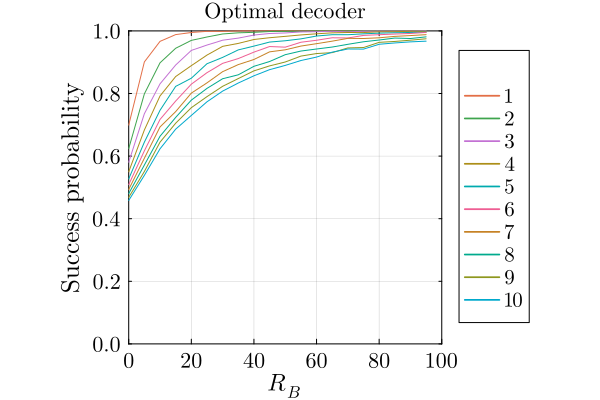

In [4]:
L = 200
plt = plot()

main_tickfont  = font("Computer Modern", 14)
inset_tickfont = font("Computer Modern", 10)

plot!([NaN], [NaN], color=:white, label=" ")
for t in 10:10:100
    prob1s = [data[(L, t, B)]["prob1"] for B in 0:5:95]
    # push!(prob1s, 1.0)
    plot!(collect(0:5:95)/100, prob1s, label=L"%$(t ÷ 10)")
end
# for t in 1000:1000:10000
#     prob1s = [data[(L, t, B)]["prob1"] for B in 0:5:45]
#     plot!(0:5:45, prob1s, label="T=$(t ÷ 10)")
# end

xticks = (0:0.2:1.0, 0:20:100)

plot!(plt, ylim=(0, 1), xlim=(0,1),
    xlabel=L"R_B", ylabel="Success probability", title="Optimal decoder",
    legend=:outerright,
    aspect_ratio=:equal,
    frame=:box,
    xticks=xticks,
    titlefont=main_tickfont,
    tickfont=main_tickfont,
    guidefont=main_tickfont,
    xguidefontsize=16,
    yguidefontsize=16,
    legendfontsize=14,)




plt

In [8]:
L = 200
plt = plot()

main_tickfont  = font("Computer Modern", 14)
inset_tickfont = font("Computer Modern", 10)

# ---- main plot ----
plot!(plt, [NaN], [NaN], color=:white, label=" ")  # dummy entry (your legend spacing)

for t in union(10:10:100, [1000,2000])
    prob1s = [data[(L, t, B)]["prob1"] for B in 0:5:95]
    plot!(plt, collect(0:5:95) ./ 100, prob1s, label=L"%$(t ÷ 10)")
end

xticks = (0:0.2:1.0, 0:20:100)

plot!(plt;
    ylim=(0, 1), xlim=(0, 1),
    xlabel=L"R_B", ylabel="Success probability", title="Optimal decoder",
    legend=:outerright,
    aspect_ratio=:equal,
    frame=:box,
    xticks=xticks,
    titlefont=main_tickfont,
    tickfont=main_tickfont,
    guidefont=main_tickfont,
    xguidefontsize=16,
    yguidefontsize=16,
    legendfontsize=14,
)

# ---- inset (bottom-right), same plot again ----
BB = bbox(0.37, 0.08, 0.4, 0.4, :bottom, :left)  # (x, y, w, h) in figure fractions
plot!(plt;
    inset=(1, BB), subplot=2,
    frame=:box,
    grid=:false,
    legend=false,
    aspect_ratio=:equal,
    xlim=(-0.1, 1), ylim=(0, 1.1),
    xticks=xticks,
    tickfont=inset_tickfont,
    guidefont=inset_tickfont,
    xlabel="", ylabel="", title="",
        xguidefontsize=12,
    yguidefontsize=12,
    legendfontsize=10,
)

# re-draw the same curves into subplot=2
plot!(plt, [NaN], [NaN], subplot=2, color=:white, label=false)
for t in 10:10:100
    prob1s = [data[(L, t, B)]["prob1"] for B in 0:5:95]
    plot!(plt, collect(0:5:95)/(t/10)/100, prob1s; subplot=2, label=false)
end

annotate!(plt, 1.17, 0.88, text(L"t", 14, "Computer Modern"), subplot=1)
annotate!(plt, 0.51, 0.15, text(L"R_B/t", 12, "Computer Modern"), subplot=2)

# savefig(plt, "optimal_decoder.pdf")

plt


KeyError: KeyError: key (200, 2000, 90) not found

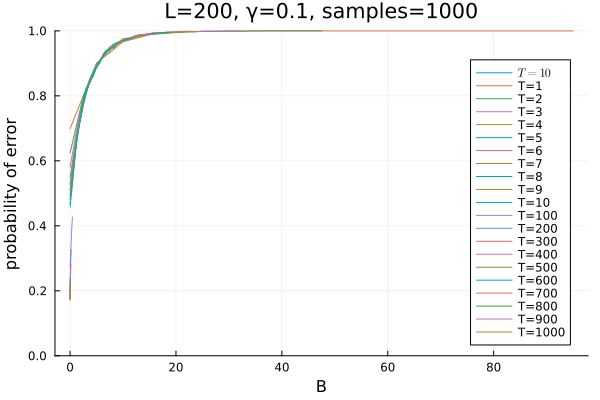

In [28]:
L = 200
plt = plot()
plot!([NaN], [NaN], label=L"T=10")
for t in 10:10:100
    prob1s = [data[(L, t, B)]["prob1"] for B in 0:5:95]
    # push!(prob1s, 1.0)
    plot!(collect(0:5:95)/(t ÷ 10), prob1s, label="T=$(t ÷ 10)")
end
for t in 1000:1000:10000
    prob1s = [data[(L, t, B)]["prob1"] for B in 0:5:45]
    plot!(collect(0:5:45)/(t ÷ 10), prob1s, label="T=$(t ÷ 10)")
end
plot!(plt, ylim=(0, 1), xlabel="B", ylabel="probability of error", title="L=200, γ=0.1, samples=1000")
display(plt)